In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from sklearn.metrics import matthews_corrcoef, confusion_matrix
from scipy.stats import fisher_exact

In [6]:
all_partitions_path = "/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/outputs/dpsi_vs_local_SHAP/all_partitions/dpsi_vs_local_SHAP_scatterplot_data_all_partitions.tsv.gz"

In [2]:
test_partitions_path = "/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/outputs/dpsi_vs_local_SHAP/test_partition/dpsi_vs_local_SHAP_scatterplot_data_test_partition.tsv.gz"

In [7]:
table = pd.read_csv(all_partitions_path, sep='\t', compression='gzip')

In [8]:
table

,Feature,RBP_KD_Target,Position,rMATS Event ID,dPSI,rMATS FDR,Bound Local SHAP,CTRL - KD Local SHAP,CTRL - KD Model Prediction (Probability),Cell Line
0,AKAP1_1_binding,AKAP1,1,2137,-0.002,1.000000,0.356984,0.357133,0.000065,HepG2
1,AKAP1_1_binding,AKAP1,1,3895,-0.000,1.000000,0.376375,0.376532,0.000175,HepG2
2,AKAP1_1_binding,AKAP1,1,6307,0.038,0.019931,0.384961,0.385121,0.004527,HepG2
3,AKAP1_1_binding,AKAP1,1,14700,-0.001,1.000000,0.418992,0.419167,0.002355,HepG2
4,AKAP1_1_binding,AKAP1,1,31976,-0.000,1.000000,0.396195,0.396361,0.000169,HepG2
...,...,...,...,...,...,...,...,...,...,...
250280,ZRANB2_6_binding,ZRANB2,6,5756,0.006,1.000000,0.000000,0.000000,0.000000,K562
250281,ZRANB2_6_binding,ZRANB2,6,9960,0.002,1.000000,0.000000,0.000000,0.000052,K562
250282,ZRANB2_6_binding,ZRANB2,6,39013,0.002,1.000000,0.000000,0.000000,0.000000,K562
250283,ZRANB2_6_binding,ZRANB2,6,43918,-0.003,1.000000,0.000000,0.000000,0.000000,K562


## Generate V1 figure 5: 2x3 grid of scatterplot with CTRL - KD SHAP

In [9]:
K562_features = ["METAP2_5_binding", "BUD13_6_binding", "YBX3_1_binding"]

In [6]:
HepG2_features = ["EFTUD2_4_binding", "UCHL5_1_binding", "EFTUD2_1_binding"]

In [7]:
# Final Figure

def top_feature_MCC_FET(data, K562_feature_list, HepG2_feature_list):
    """
    Creates a 2x3 figure of CTRL - KD Local SHAP vs dPSI scatterplots.
    Adds MCC + Fisher's exact test (odds ratio + p-value) based on sign agreement.
    Includes a global legend for significance.

    Parameters:
    -----------
    data : DataFrame
    K562_feature_list : list
    HepG2_feature_list : list
    """

    plt.style.use(
        "/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/"
        "analysis/07_reece_biological_validations/paper.mplstyle"
    )

    cell_lines = ['HepG2', 'K562']
    feature_lists = {
        'HepG2': HepG2_feature_list,
        'K562':  K562_feature_list,
    }

    fig, axes = plt.subplots(
        nrows=2, ncols=3,
        figsize=(18, 10),
    )

    legend_handles = None  # store once

    for row_idx, cell_line in enumerate(cell_lines):
        features = feature_lists[cell_line]

        for col_idx, feature in enumerate(features):
            ax = axes[row_idx, col_idx]

            # ------------------------------------------------------------------
            # 1. Subset & significance filter
            # ------------------------------------------------------------------
            feature_subset = data[
                (data['Cell Line'] == cell_line) &
                (data['Feature'] == feature)
            ].copy()

            feature_subset['Significance'] = (
                (feature_subset['dPSI'].abs() > 0) &
                (feature_subset['rMATS FDR'] <= 0.1)
            ).astype(int)

            significant_subset = feature_subset[feature_subset['Significance'] == 1].copy()
            num_significant = len(significant_subset)

            # ------------------------------------------------------------------
            # 2. Scatter plot (with labels for legend)
            # ------------------------------------------------------------------
            if len(feature_subset) > 0:

                sig_mask = (
                    (feature_subset['dPSI'].abs() > 0) &
                    (feature_subset['rMATS FDR'] <= 0.1)
                )

                sig_scatter = ax.scatter(
                    feature_subset.loc[sig_mask, 'CTRL - KD Local SHAP'],
                    feature_subset.loc[sig_mask, 'dPSI'],
                    color='tab:blue',
                    alpha=0.5,
                    s=30,
                    label='Significant'
                )

                nonsig_scatter = ax.scatter(
                    feature_subset.loc[~sig_mask, 'CTRL - KD Local SHAP'],
                    feature_subset.loc[~sig_mask, 'dPSI'],
                    color='lightgrey',
                    alpha=0.5,
                    s=30,
                    label='Nonsignificant'
                )

                # Save handles once (first valid plot)
                if legend_handles is None:
                    legend_handles = [sig_scatter, nonsig_scatter]

            # ------------------------------------------------------------------
            # 3. MCC + Fisher's exact test
            # ------------------------------------------------------------------
            if num_significant >= 10:
                dpsi_vals = significant_subset['dPSI'].values
                shap_vals = significant_subset['CTRL - KD Local SHAP'].values

                y_true = np.sign(dpsi_vals).astype(int)
                y_pred = np.sign(shap_vals).astype(int)

                mcc = matthews_corrcoef(y_true, y_pred)

                same_sign = (
                    ((shap_vals > 0) & (dpsi_vals > 0)) |
                    ((shap_vals < 0) & (dpsi_vals < 0))
                )
                sign_concordance = same_sign.sum() / num_significant * 100

                tp = np.sum((shap_vals > 0) & (dpsi_vals > 0))
                tn = np.sum((shap_vals < 0) & (dpsi_vals < 0))
                fp = np.sum((shap_vals > 0) & (dpsi_vals < 0))
                fn = np.sum((shap_vals < 0) & (dpsi_vals > 0))

                contingency_table = np.array([[tp, fp],
                                              [fn, tn]])

                odds_ratio, p_value = fisher_exact(contingency_table)

                textstr = (
                    f"Sign concordance: {sign_concordance:.1f}%\n"
                    f"FET P-value: {p_value:.2e}"
                )

                props = dict(boxstyle='round', facecolor='white',
                             edgecolor='black', alpha=0.8)

                ax.text(0.05, 0.05, textstr,
                        transform=ax.transAxes,
                        fontsize=11, verticalalignment='bottom',
                        bbox=props)

            else:
                ax.text(0.05, 0.05, "n < 10\n(MCC/Fisher not computed)",
                        transform=ax.transAxes,
                        fontsize=11, verticalalignment='bottom',
                        color='grey')

            # ------------------------------------------------------------------
            # 4. Axes formatting
            # ------------------------------------------------------------------
            ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
            ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
            ax.grid(True, alpha=0.3)
            ax.set_xlabel(r"$\Delta$LocalSHAP", fontsize=12, labelpad=8)
            ax.set_ylabel(r"$\Delta\Psi$", fontsize=12, labelpad=8)
            ax.tick_params(axis='both', labelsize=10)

            parts = feature.split('_')
            rbp_name = parts[0]
            position = parts[1] if len(parts) > 1 else ''
            ax.set_title(f"{rbp_name} Position {position}", fontsize=13, pad=10)

        axes[row_idx, 0].annotate(
            cell_line,
            xy=(-0.25, 0.5), xycoords='axes fraction',
            fontsize=16, fontweight='bold',
            rotation=90, va='center', ha='center'
        )

    fig.suptitle(r"$\Delta$LocalSHAP vs. $\Delta\Psi$ by Feature and Cell Line",
                 fontsize=18, y=1.02)

    # ------------------------------------------------------------------
    # Global legend
    # ------------------------------------------------------------------
    if legend_handles is not None:
        fig.legend(
            legend_handles,
            ['Significant', 'Nonsignificant'],
            loc='upper right',
            frameon=False,
            fontsize=14,         
            markerscale=1.5       
        )

    plt.tight_layout()
    plt.show()

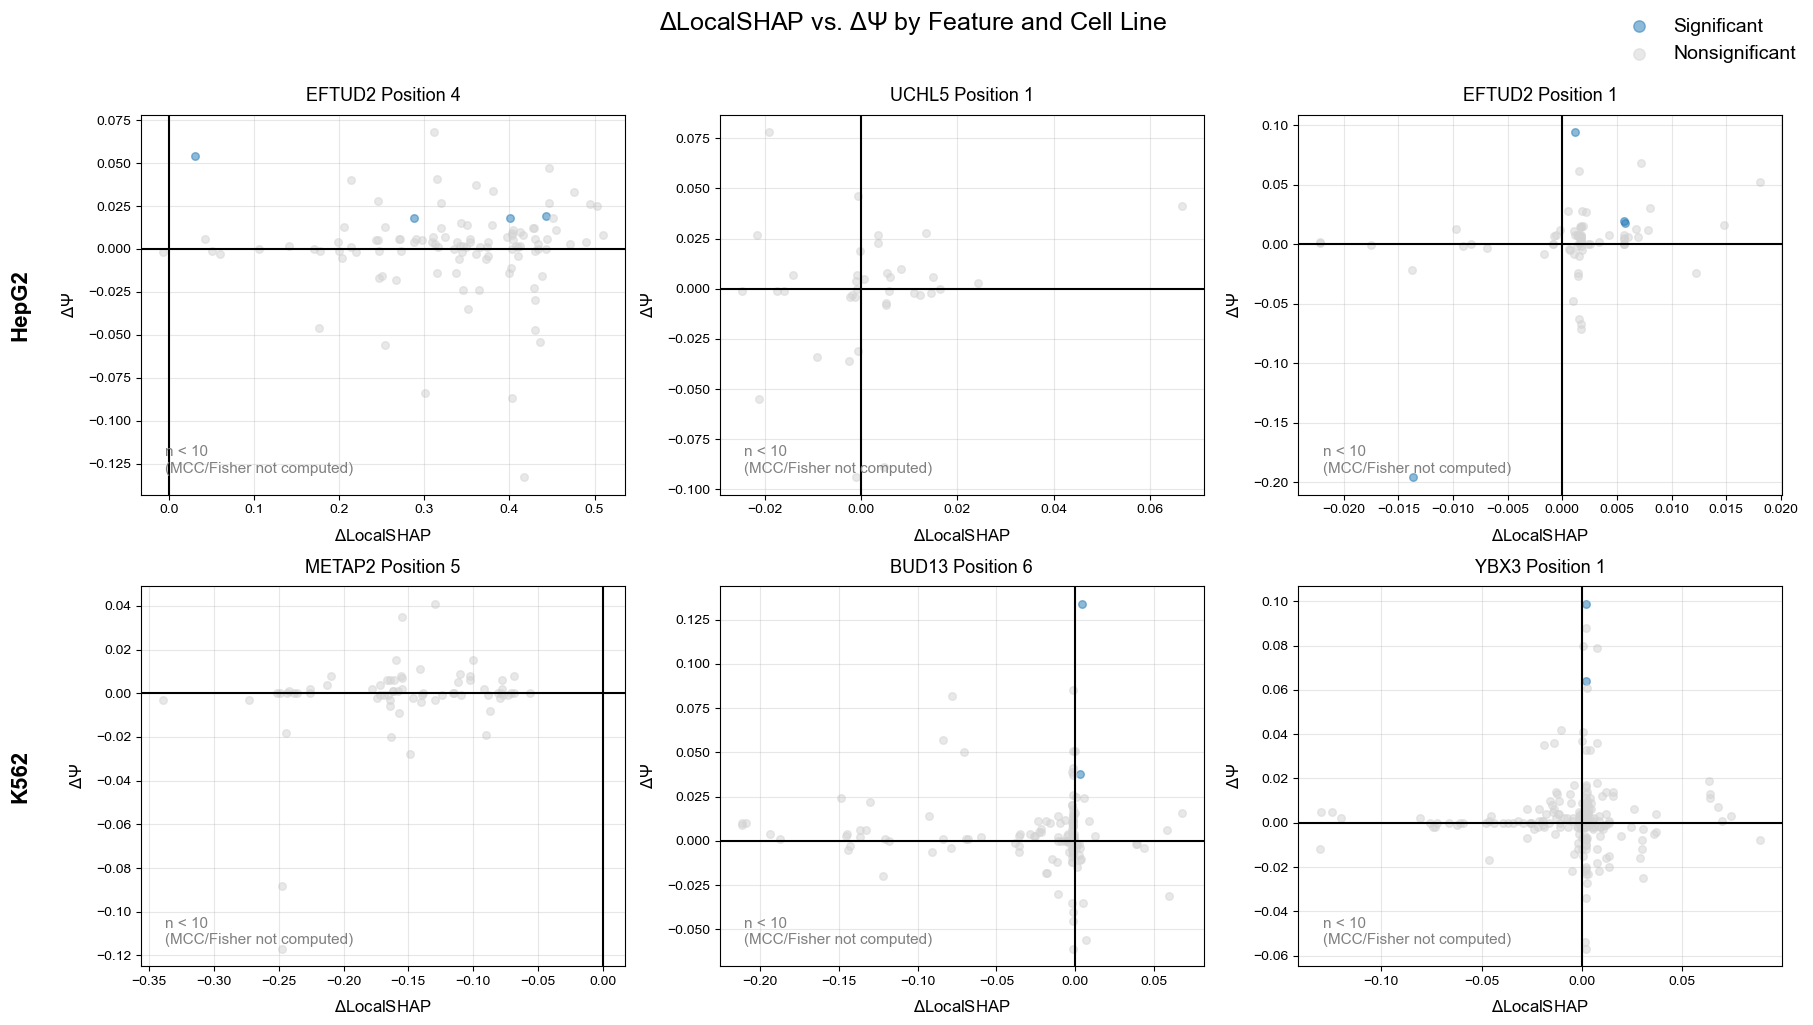

In [8]:
top_feature_MCC_FET(table, K562_features, HepG2_features)

## Generate scatterplot for one feature with JUST CTRL SHAP

In [30]:
feature = ['ELAVL1_2_binding']

In [31]:
cell_line = ['K562']

In [28]:
def one_feature_scatter(data, feature, cell_line):
    
    plt.style.use(
        "/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/"
        "analysis/07_reece_biological_validations/paper.mplstyle"
    )

    # ------------------------------------------------------------------
    # 1. Subset & significance filter
    # ------------------------------------------------------------------
    cell_line = cell_line[0]
    feature = feature[0]
    
    feature_subset = data[
        (data['Cell Line'] == cell_line) &
        (data['Feature'] == feature)
    ].copy()

    sig_mask = (
        (feature_subset['dPSI'].abs() > 0) &
        (feature_subset['rMATS FDR'] <= 0.1)
    )

    # ------------------------------------------------------------------
    # 2. Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(
        feature_subset.loc[~sig_mask, 'Bound Local SHAP'],
        feature_subset.loc[~sig_mask, 'dPSI'],
        color='lightgrey',
        alpha=0.5,
        s=30,
        label='Nonsignificant'
    )

    ax.scatter(
        feature_subset.loc[sig_mask, 'Bound Local SHAP'],
        feature_subset.loc[sig_mask, 'dPSI'],
        color='tab:blue',
        alpha=0.5,
        s=30,
        label='Significant'
    )

    # ------------------------------------------------------------------
    # 3. Axes formatting
    # ------------------------------------------------------------------
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r"CTRL LocalSHAP", fontsize=12, labelpad=8)
    ax.set_ylabel(r"$\Delta\psi$", fontsize=12, labelpad=8)
    ax.tick_params(axis='both', labelsize=10)

    parts = feature.split('_')
    rbp_name = parts[0]
    position = parts[1] if len(parts) > 1 else ''
    ax.set_title(f"{rbp_name} Position {position} — {cell_line}", fontsize=13, pad=10)

    ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),
    frameon=False,
    fontsize=12,
    markerscale=1.5
)

    plt.tight_layout()
    plt.show()

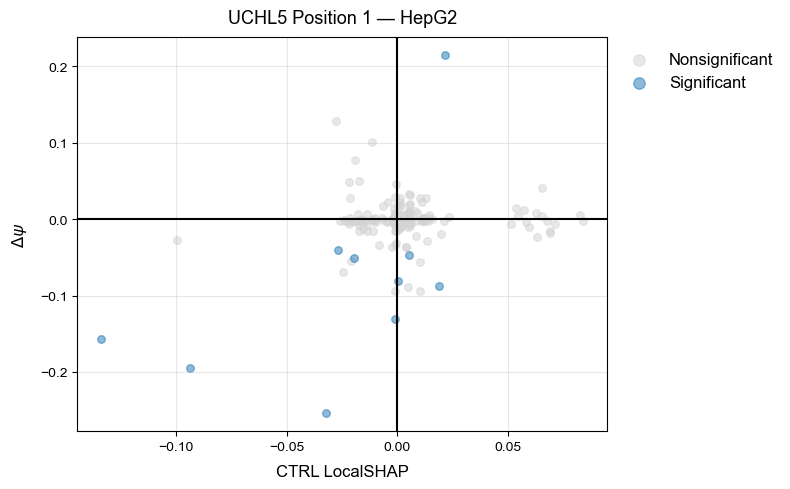

In [29]:
one_feature_scatter(table, feature, cell_line)

## Summarize test/all partition data

In [11]:
def summarize_mmc(data):

    cell_lines = ['HepG2', 'K562']
    features = data['Feature'].unique()
    rows = []
    
    for feature in features:
        parts = feature.split('_')
        rbp_name = parts[0]
        position = parts[1]
        rbp_label = f"{rbp_name} Position {position}"

        for cell_line in cell_lines:
    
            # ------------------------------------------------------------------
            # 1. Subset & significance filter
            # ------------------------------------------------------------------
            feature_subset = data[
                (data['Cell Line'] == cell_line) &
                (data['Feature'] == feature)
            ].copy()
    
            feature_subset['Significance'] = (
                (feature_subset['dPSI'].abs() > 0) &
                (feature_subset['rMATS FDR'] <= 0.1)
            ).astype(int)
    
            significant_subset = feature_subset[feature_subset['Significance'] == 1].copy()
            num_significant = len(significant_subset)
    
            # ------------------------------------------------------------------
            # 2. MCC calculation (requires ≥ 10 significant events)
            # ------------------------------------------------------------------
    
            if num_significant >= 10:
                dpsi_vals = significant_subset['dPSI'].values
                shap_vals = significant_subset['CTRL - KD Local SHAP'].values

                y_true = np.sign(dpsi_vals).astype(int)
                y_pred = np.sign(shap_vals).astype(int)

                mcc = matthews_corrcoef(y_true, y_pred)

                same_sign = (
                    ((shap_vals > 0) & (dpsi_vals > 0)) |
                    ((shap_vals < 0) & (dpsi_vals < 0))
                )
                sign_concordance = same_sign.sum() / num_significant * 100

                tp = np.sum((shap_vals > 0) & (dpsi_vals > 0))
                tn = np.sum((shap_vals < 0) & (dpsi_vals < 0))
                fp = np.sum((shap_vals > 0) & (dpsi_vals < 0))
                fn = np.sum((shap_vals < 0) & (dpsi_vals > 0))

                contingency_table = np.array([[tp, fp],
                                              [fn, tn]])

                odds_ratio, p_value = fisher_exact(contingency_table)

                textstr = (
                    f"Sign concordance: {sign_concordance:.1f}%\n"
                    f"FET P-value: {p_value:.2e}"
                )
            
    
                rows.append({
                    'Feature': rbp_label,
                    'Cell Line': cell_line,
                    'Significant Events': num_significant,
                    'Sign Concordance': sign_concordance,
                    'MCC': mcc,
                    'OR': odds_ratio,
                    'FET Pvalue': p_value,
                    'TP': tp,
                    'FP': fp,
                    'TN': tn,
                    'FN': fn
                })

    return pd.DataFrame(rows).reset_index(drop=True)

In [12]:
test = summarize_mmc(table)

/home/bhd5qr/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/bhd5qr/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [13]:
test.sort_values('Sign Concordance', ascending=False).to_csv("test_partition_all_metrics_summary.csv", index=False)